<a href="https://colab.research.google.com/github/amigli/Q-Bert_RL/blob/main/Notebook/DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training e Test con DQN
In questo notebook è presente il training di Q*Bert sfruttando l'algoritmo DQN

## Download Repository

Download della repository per utilizzare le classi create su Google Colab

In [1]:
from google.colab import userdata

In [2]:
! git clone https://{userdata.get('TokenGithub')}"@github.com/amigli/Q-Bert_RL.git"

Cloning into 'Q-Bert_RL'...
remote: Enumerating objects: 507, done.
remote: Counting objects: 100% (226/226), done.
remote: Compressing objects: 100% (192/192), done.
Receiving objects: 100% (507/507), 8.96 MiB | 8.48 MiB/s, done.
remote: Total 507 (delta 151), reused 69 (delta 34), pack-reused 281 (from 1)
Resolving deltas: 100% (314/314), done.


In [3]:
%cd Q-Bert_RL

/content/Q-Bert_RL


## Installazione dei requirements

Vengono installati tutti i moduli necessari dal file requirements.txt

In [4]:
!pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 20.7 MB/s eta 0:00:00


In [5]:
!pip install ale-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 11.8 MB/s eta 0:00:00


In [6]:
!pip install moviepy

## Training

In [8]:
import gymnasium as gym
import ale_py
from tqdm.notebook import tqdm, trange
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo
from EnvironmentWrappers.ObsRewardWrapper import ObsRewardWrapper
from Algorithms.QBertAgent_DQN import DQNAgent

In [9]:
class OurRewardWrapper(gym.RewardWrapper):
  def reward(self, reward):
    if reward < 0:
      return -1

    if reward > 0:
      return 1

    return 0

In [15]:
gym.register_envs(ale_py)

learning_rate = 0.001
n_episodes = 10000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.1

env = gym.make("ALE/Qbert-ram-v5")
env =  ObsRewardWrapper(env)
env = OurRewardWrapper(env)
env = RecordEpisodeStatistics(env, buffer_length=n_episodes)
obs, info = env.reset()

state_dim = obs.shape[0]
action_dim = env.action_space.n
agent = DQNAgent(state_dim, action_dim, lr=0.0001, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, buffer_size=10000)

# TRAINING
batch_size = 64
for episode in trange(n_episodes, desc="Training Progress"):
    obs, info = env.reset()
    done = False

    total_reward = 0
    while not done:
        action = agent.act(obs, True)
        next_obs, reward, terminated, truncated, info = env.step(action)

        done =  terminated or truncated
        agent.remember(obs, action, reward, next_obs, done)
        obs = next_obs
        total_reward += reward
        agent.replay(batch_size)

    # tqdm.write(f"Episode: {episode + 1}, Total Reward: {total_reward}")

env.close()


Training Progress:   0%|          | 0/10000 [00:00<?, ?it/s]

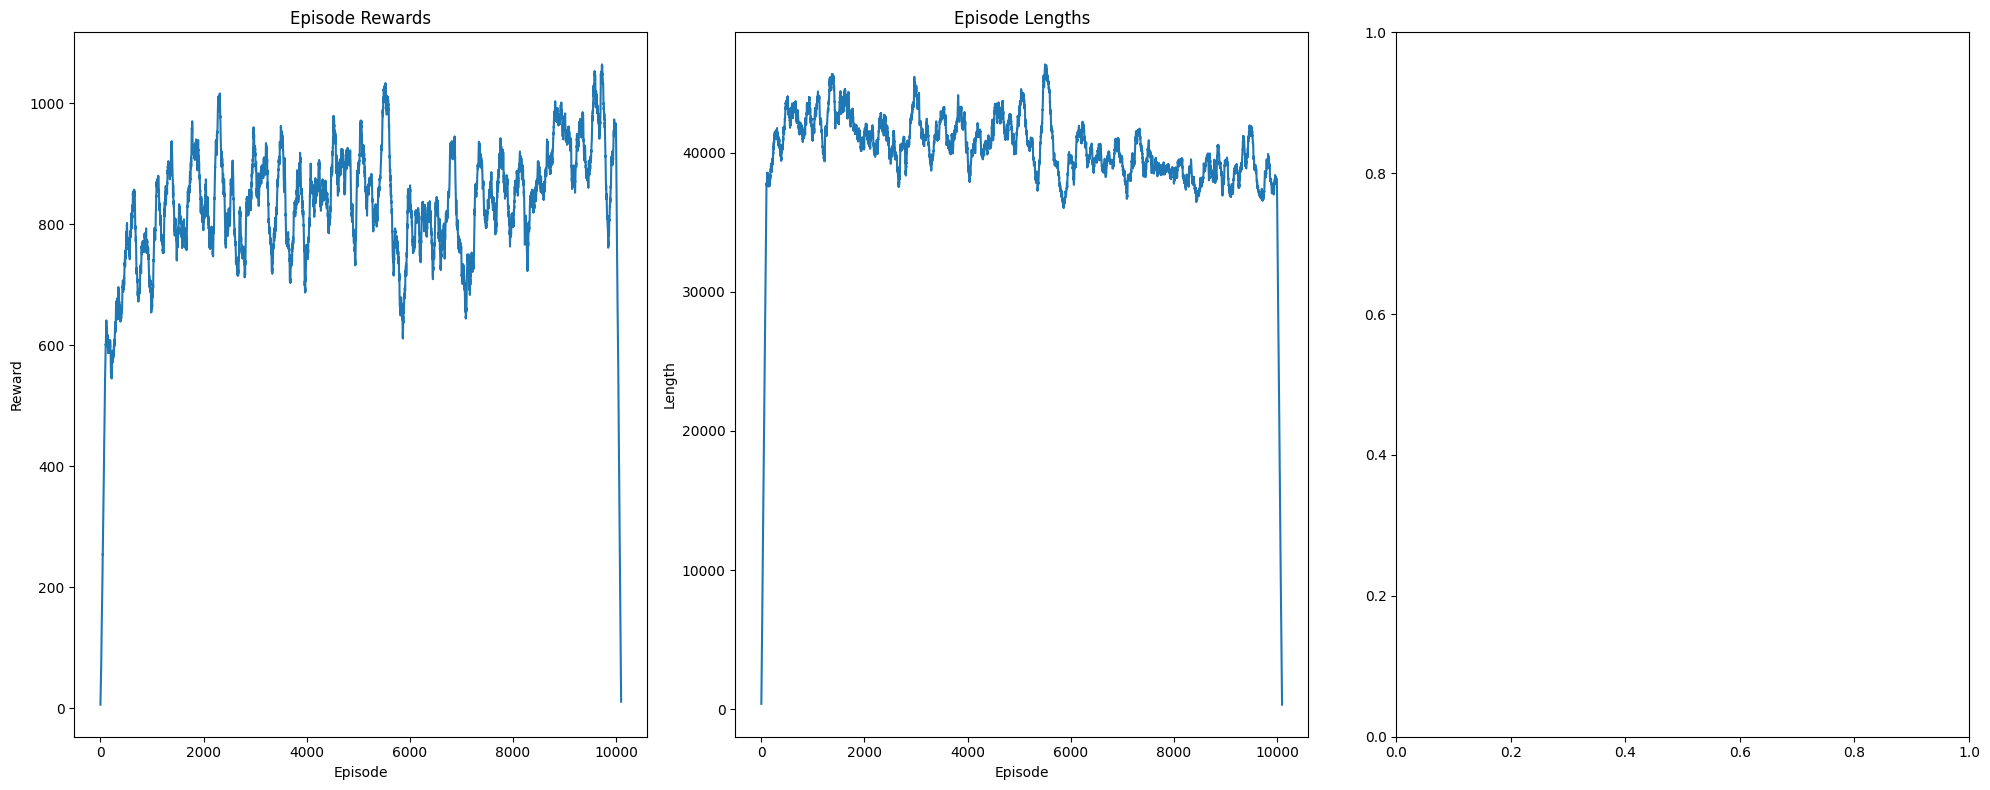

In [16]:
from matplotlib import pyplot as plt
import numpy as np

# visualize the episode rewards, episode length and training error in one figure
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

# np.convolve will compute the rolling mean for 100 episodes

axs[0].plot(np.convolve(env.return_queue, np.ones(100)))
axs[0].set_title("Episode Rewards")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Reward")

axs[1].plot(np.convolve(env.length_queue, np.ones(100)))
axs[1].set_title("Episode Lengths")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Length")

# axs[2].plot(np.convolve(agent.training_error, np.ones(100)))
# axs[2].set_title("Training Error")
# axs[2].set_xlabel("Episode")
# axs[2].set_ylabel("Temporal Difference")

plt.tight_layout()
plt.show()

# Utilizzo Policy

Di seguito viente utilizzata la policy precedentemente calcolata per registrare degli episodi

In [20]:
num_eval_episodes = 100

env = gym.make("ALE/Qbert-ram-v5", render_mode="rgb_array")
env =  ObsRewardWrapper(env)
env = OurRewardWrapper(env)
env = RecordVideo(env, video_folder="videos_first", name_prefix="eval",
                  episode_trigger=lambda x: True)
env = RecordEpisodeStatistics(env, buffer_length=num_eval_episodes)


for episode_num in range(num_eval_episodes):
    obs, info = env.reset()
    done = False

    while not done:
        action = agent.act(obs, False)
        next_obs, reward, terminated, truncated, info = env.step(action)
        obs =  next_obs

        done = terminated or truncated
env.close()

print(f'Episode time taken: {env.time_queue}')
print(f'Episode total rewards: {env.return_queue}')
print(f'Episode lengths: {env.length_queue}')

print("Training terminato")

Episode time taken: deque([1.080923, 1.034804, 1.020568, 0.817594, 0.998031, 0.988891, 0.987652, 0.805684, 1.011248, 0.841325, 1.013322, 1.003206, 0.993203, 0.820872, 1.047756, 0.80707, 0.814779, 1.000853, 1.06126, 0.996378, 0.990809, 1.002088, 0.990221, 0.979165, 1.017834, 1.037472, 0.877924, 1.038582, 0.851358, 0.847453, 1.050467, 1.019651, 1.032826, 0.843378, 1.062241, 1.049594, 1.068852, 1.031577, 1.030546, 1.033447, 1.025228, 1.036311, 0.838935, 1.026995, 1.034165, 0.869342, 1.035514, 1.022383, 1.019081, 1.07109, 0.802291, 0.987197, 0.846146, 0.984403, 1.015806, 0.995823, 1.005926, 0.998989, 1.004819, 0.993292, 1.001434, 0.990595, 0.98609, 0.834202, 1.02399, 1.001381, 0.99869, 0.995611, 0.992923, 0.982446, 0.984974, 0.994422, 1.019604, 1.047065, 0.816295, 0.998945, 0.984555, 0.82003, 0.984757, 0.994989, 0.999253, 1.011118, 1.023464, 1.004276, 0.99273, 0.813278, 0.986236, 0.996425, 0.82182, 1.002125, 1.00712, 1.024648, 0.990304, 0.995307, 0.810946, 0.841732, 0.99928, 1.007605, 0.99

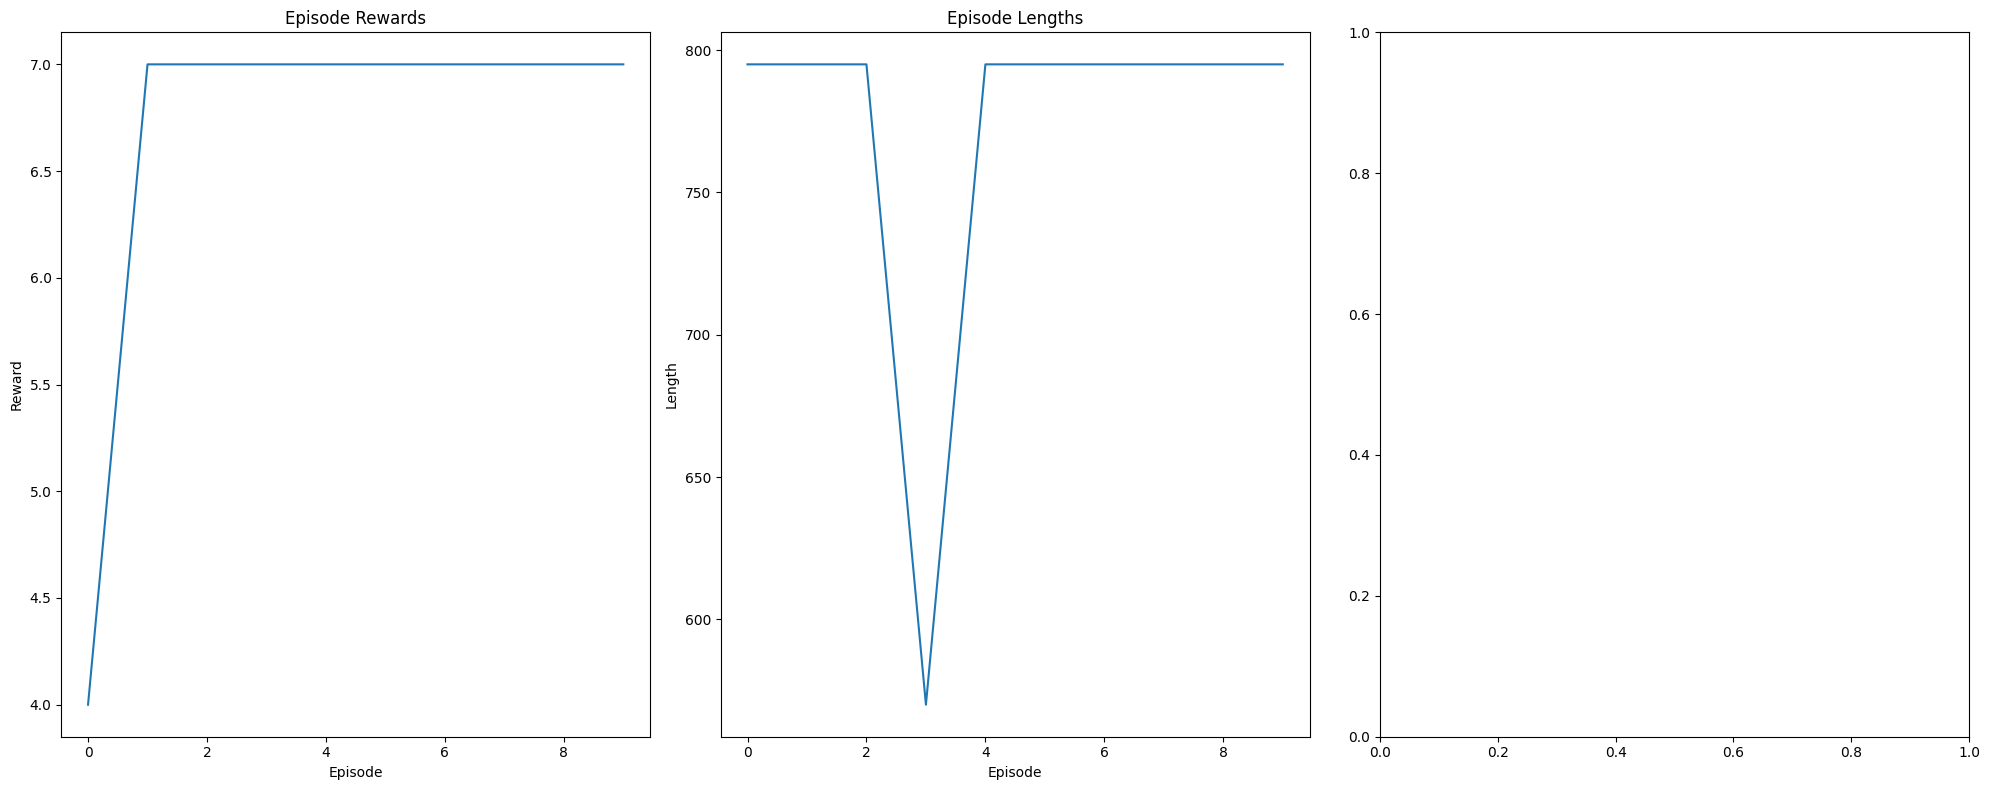

In [13]:
from matplotlib import pyplot as plt
import numpy as np

# visualize the episode rewards, episode length and training error in one figure
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

# np.convolve will compute the rolling mean for 100 episodes

axs[0].plot(env.return_queue)
axs[0].set_title("Episode Rewards")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Reward")

axs[1].plot(env.length_queue)
axs[1].set_title("Episode Lengths")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Length")

# axs[2].plot(np.convolve(agent.training_error, np.ones(10)))
# axs[2].set_title("Training Error")
# axs[2].set_xlabel("Episode")
# axs[2].set_ylabel("Temporal Difference")

plt.tight_layout()
plt.show()

In [22]:
agent.save("DQN_Modelnew")